# Modelo SIR — COVID-19 no Brasil (1ª Onda: Mar–Set 2020)

**Disciplina:** Modelagem Computacional  
**Fonte dos dados:** Brasil.IO — Secretarias Estaduais de Saúde, tratados por Álvaro Justen  
**Referência:** Tavares, J.N. (2017). Modelo SIR em epidemiologia. *Rev. Ciência Elementar*, V5(02):020.

---

## Objetivo

Aplicar o modelo SIR para simular a COVID-19 no Brasil (1ª onda) usando:
- **Método de Euler** para resolver numericamente o sistema de EDOs
- **scipy.optimize** para calibrar o parâmetro β a partir dos dados reais
- Cálculo do **número de reprodução efetivo R₀**

## Por que a 1ª onda?

O modelo SIR assume população fechada, sem vacinação, imunidade permanente e uma única cepa. A 1ª onda (mar–set/2020) é o período em que todas essas hipóteses são mais razoáveis.

---
## Seção 1 — Importação das Bibliotecas

In [18]:
import os
import numpy as np                          # Operações numéricas e vetores
import pandas as pd                         # Manipulação de dados tabulares
import matplotlib.pyplot as plt             # Geração de gráficos
import matplotlib.dates as mdates           # Formatação de datas nos gráficos
from pathlib import Path                    # Navegação de caminhos de arquivo
from scipy.optimize import minimize_scalar  # Otimização para calibrar beta

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
## Seção 2 — Carregamento e Preparação dos Dados

### 2.1 Leitura do dataset

O arquivo `caso_full.csv` é localizado pela função `encontrar_csv()`, que sobe até 3 níveis a partir do diretório de trabalho — garantindo funcionamento independente de onde o kernel inicia.

In [ ]:
def encontrar_csv(nome='caso_full.csv', niveis=3):
    caminho = Path(os.getcwd())
    for _ in range(niveis + 1):
        candidato = caminho / nome
        if candidato.exists():
            return candidato
        caminho = caminho.parent
    raise FileNotFoundError(
        f'{nome} nao encontrado ate {niveis} niveis acima de: {os.getcwd()}'
    )

CSV_PATH = encontrar_csv('caso_full.csv')
print(f'CSV encontrado em: {CSV_PATH.resolve()}')

df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Dimensoes: {df_raw.shape}')
print(f'Colunas: {list(df_raw.columns)}')

In [ ]:
# Filtro: apenas registros de nivel estadual (place_type == 'state')
df_estados = df_raw[df_raw['place_type'] == 'state'].copy()

df_estados['date'] = pd.to_datetime(df_estados['date'])
for col in ['new_confirmed', 'last_available_confirmed', 'estimated_population']:
    df_estados[col] = pd.to_numeric(df_estados[col], errors='coerce').fillna(0)

print(f'Registros estaduais: {len(df_estados):,}')
print(f'Periodo: {df_estados["date"].min().date()} a {df_estados["date"].max().date()}')

### 2.2 Agregação nacional e população total

Somamos os 27 estados para obter os totais diários do Brasil.

In [ ]:
N = int(df_estados.groupby('state')['estimated_population'].max().sum())
print(f'Populacao total (N): {N:,} habitantes')

df_brasil = (
    df_estados
    .groupby('date')[['new_confirmed', 'last_available_confirmed']]
    .sum().reset_index().sort_values('date').reset_index(drop=True)
)
print(f'Total de dias com dados: {len(df_brasil)}')

### 2.3 Recorte da 1ª onda e suavização

**Recorte:** março a setembro de 2020.  
**Média móvel de 7 dias:** elimina o efeito de subnotificação de fim de semana (secretarias reportavam menos aos domingos e compensavam na segunda-feira).

In [19]:
mask = (df_brasil['date'] >= '2020-03-01') & (df_brasil['date'] <= '2020-09-30')
df_onda1 = df_brasil[mask].copy().reset_index(drop=True)

df_onda1['casos_suavizados'] = (
    df_onda1['new_confirmed'].rolling(window=7, min_periods=1, center=True).mean()
)

print(f'Dias na 1a onda: {len(df_onda1)}')
print(f'Pico diario suavizado: {int(df_onda1["casos_suavizados"].max()):,} casos')
print(f'Casos em 30/09/2020: {int(df_onda1.iloc[-1]["last_available_confirmed"]):,}')

Dias na 1a onda: 214
Pico diario suavizado: 47,514 casos
Casos em 30/09/2020: 4,817,365


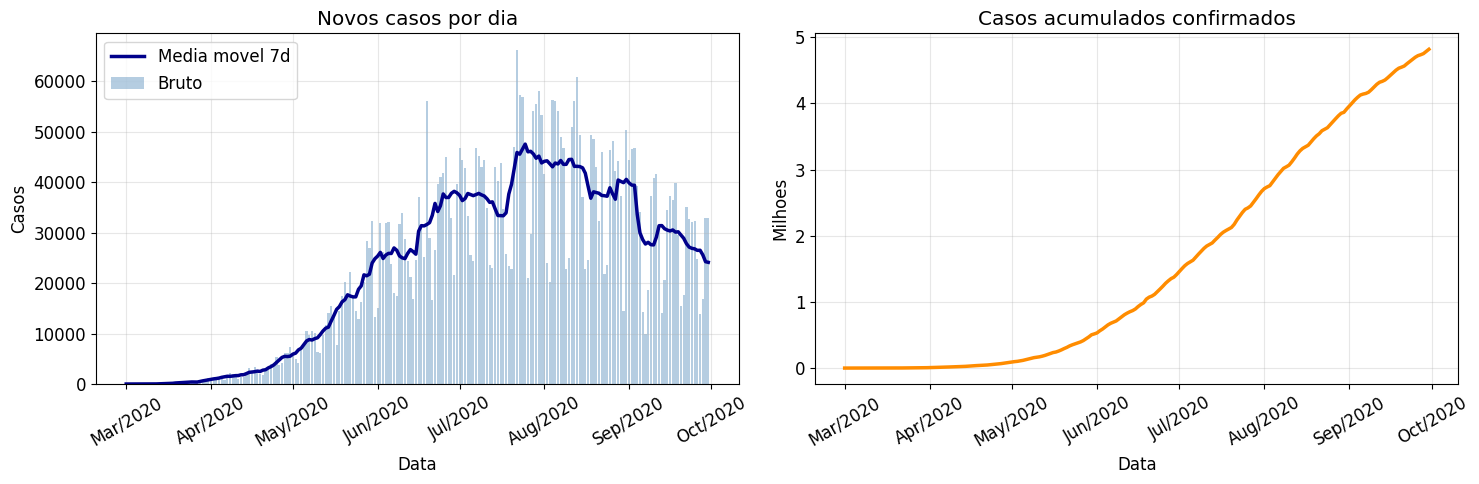

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(df_onda1['date'], df_onda1['new_confirmed'], color='steelblue', alpha=0.4, label='Bruto')
axes[0].plot(df_onda1['date'], df_onda1['casos_suavizados'], color='darkblue', lw=2.5, label='Media movel 7d')
axes[0].set_title('Novos casos por dia')
axes[0].set_xlabel('Data'); axes[0].set_ylabel('Casos'); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].plot(df_onda1['date'], df_onda1['last_available_confirmed']/1e6, color='darkorange', lw=2.5)
axes[1].set_title('Casos acumulados confirmados')
axes[1].set_xlabel('Data'); axes[1].set_ylabel('Milhoes')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('dados_exploratorios.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Seção 3 — Fundamentos do Modelo SIR

| Compartimento | Descrição |
|---|---|
| **S(t)** | Suscetíveis — podem se infectar |
| **I(t)** | Infectados — estão doentes e transmitem |
| **R(t)** | Removidos — recuperados (imunes) ou óbitos |

Conservação: **S(t) + I(t) + R(t) = N** para todo t.

### Sistema de EDOs

$$\frac{dS}{dt} = -\beta \frac{S \cdot I}{N} \qquad
\frac{dI}{dt} = \beta \frac{S \cdot I}{N} - \gamma I \qquad
\frac{dR}{dt} = \gamma I$$

### Por que não tem solução analítica?

O termo dS/dt contém o produto S·I — é **não-linear**. Não é separável, não é linear, não é exata. Nenhum método analítico das aulas se aplica. Por isso usamos o **Método de Euler**.

---
## Seção 4 — Implementação via Método de Euler

$$S_{n+1} = S_n + \Delta t\left(-\beta\frac{S_nI_n}{N}\right)$$
$$I_{n+1} = I_n + \Delta t\left(\beta\frac{S_nI_n}{N} - \gamma I_n\right)$$
$$R_{n+1} = R_n + \Delta t\left(\gamma I_n\right)$$

Os três compartimentos são atualizados **simultaneamente** a cada passo (método explícito).

In [21]:
def sir_euler(beta, gamma, N, S0, I0, R0_init, n_dias, dt=1.0):
    """
    Resolve o sistema SIR pelo Metodo de Euler.

    Parametros
    ----------
    beta    : taxa de transmissao (dia-1)
    gamma   : taxa de recuperacao (dia-1)
    N       : populacao total
    S0, I0, R0_init : condicoes iniciais
    n_dias  : numero de dias a simular
    dt      : passo de tempo (padrao = 1 dia)

    Retorna
    -------
    S, I, R : arrays com a evolucao temporal dos compartimentos
    """
    n = int(n_dias / dt)
    S, I, R = np.zeros(n+1), np.zeros(n+1), np.zeros(n+1)
    S[0], I[0], R[0] = S0, I0, R0_init

    for i in range(n):
        dS = -beta * S[i] * I[i] / N               # suscetiveis diminuem
        dI =  beta * S[i] * I[i] / N - gamma * I[i] # infectados: entrada - saida
        dR =  gamma * I[i]                           # removidos crescem

        # Atualizacao simultanea: y_{n+1} = y_n + dt * dy/dt
        S[i+1] = S[i] + dt * dS
        I[i+1] = I[i] + dt * dI
        R[i+1] = R[i] + dt * dR

    return S, I, R

print('Funcao sir_euler() definida.')

Funcao sir_euler() definida.


---
## Seção 5 — Condições Iniciais e Parâmetros Fixos

### Parâmetro γ — fixado pela literatura

Para a cepa original do SARS-CoV-2, o período infeccioso médio é **D = 10 dias**:
$$\gamma = 1/D = 1/10 = 0{,}1 \text{ dia}^{-1}$$

Fixar γ pela literatura e estimar apenas β garante consistência biológica.

### Condições iniciais — 16 de março de 2020

Data em que o Brasil declarou emergência nacional, com dados confiáveis suficientes.

In [22]:
N         = 211_755_692   # Populacao total IBGE 2020 (via Brasil.IO)
gamma     = 1 / 10        # D = 10 dias de periodo infeccioso
print(f'gamma = {gamma:.3f} dia-1  (periodo infeccioso = {1/gamma:.0f} dias)')

DATA_INICIO = '2020-03-16'
df_sim = df_onda1[df_onda1['date'] >= DATA_INICIO].copy().reset_index(drop=True)
n_dias = len(df_sim) - 1

# I0: casos acumulados no dia de inicio
# (proxy conservador — subestimativa por subnotificacao)
I0      = float(df_sim.iloc[0]['last_available_confirmed'])
R0_init = 0.0            # zero recuperados conhecidos no inicio
S0      = N - I0 - R0_init

print(f'Inicio: {DATA_INICIO} | Dias: {n_dias}')
print(f'N={N:,}  I0={I0:,.0f}  R0_init={R0_init:.0f}  S0={S0:,.0f}')
print(f'Verificacao S0+I0+R0 = {S0+I0+R0_init:,.0f} (deve ser N)')

gamma = 0.100 dia-1  (periodo infeccioso = 10 dias)
Inicio: 2020-03-16 | Dias: 198
N=211,755,692  I0=280  R0_init=0  S0=211,755,412
Verificacao S0+I0+R0 = 211,755,692 (deve ser N)


---
## Seção 6 — Calibração do Parâmetro β

### Por que calibrar contra novos casos diários?

A função de erro compara os **novos infectados por dia do modelo** com a **média móvel de 7 dias dos dados reais**. Isso é crucial:

- Calibrar contra casos acumulados (como se faz ingenuamente) não force o modelo a   reproduzir a *forma* da curva epidêmica. O otimizador encontra um β que ajusta a   fase inicial, mas o modelo depois se desvia completamente.
- A curva de **novos casos por dia** tem informação sobre a *taxa* de crescimento,   que é exatamente o que β controla.

### Definição do MSE

$$\text{MSE}(\beta) = \frac{1}{T}\sum_{t=1}^{T}\left[\underbrace{S(t-1)-S(t)}_{\text{novas infecções do modelo}} - \underbrace{\bar{c}(t)}_{\text{média móvel 7d dos dados}}\right]^2$$

`minimize_scalar` busca o β ótimo no intervalo biológico [0,05 ; 0,50].

### Limitação fundamental do modelo

> O SIR com β **constante** não consegue reproduzir a queda pós-pico da epidemia. O pico real ocorreu por redução do β ao longo do tempo (medidas de isolamento), **não** por imunidade de rebanho. O modelo calibrado captura bem a fase de crescimento, mas diverge após o pico — o que é esperado e discutido na Seção 8.

In [23]:
# Alvo de calibracao: media movel de 7 dias dos novos casos diarios
casos_diarios_obs = df_sim['casos_suavizados'].values  # shape: (n_dias+1,)

def funcao_erro(beta):
    """
    MSE entre novos casos diarios do modelo (-dS/dt) e media movel 7d dos dados.

    Calibrar contra a curva diaria (e nao acumulados) e essencial para que o
    otimizador capture corretamente a taxa de crescimento da epidemia.
    """
    S, I, R = sir_euler(beta, gamma, N, S0, I0, R0_init, n_dias)
    novos_modelo = -np.diff(S)                # shape: (n_dias,) — novas infeccoes/dia
    alvo         = casos_diarios_obs[1:]       # alinha: dia 1 em diante
    n            = min(len(novos_modelo), len(alvo))
    return np.mean((novos_modelo[:n] - alvo[:n]) ** 2)

print('Calibrando beta...')
res        = minimize_scalar(funcao_erro, bounds=(0.05, 0.50), method='bounded')
beta_otimo = res.x

print(f'beta calibrado = {beta_otimo:.4f} dia-1')
print(f'MSE minimo     = {res.fun:.2e}')

Calibrando beta...
beta calibrado = 0.1380 dia-1
MSE minimo     = 5.46e+08


---
## Seção 7 — Simulação e Resultados

In [ ]:
S, I, R = sir_euler(beta_otimo, gamma, N, S0, I0, R0_init, n_dias)
datas_sim = pd.date_range(start=DATA_INICIO, periods=len(S), freq='D')

# R0 = beta/gamma
# Interpretacao: numero medio de pessoas que um infectado contagia
# em uma populacao 100% suscetivel, antes de se recuperar.
# Aqui e o R0 *efetivo* — ja com os efeitos parciais das intervencoes.
R0_valor = beta_otimo / gamma

print('=' * 55)
print(f'beta   = {beta_otimo:.4f} dia-1')
print(f'gamma  = {gamma:.4f} dia-1')
print(f'R0     = {R0_valor:.2f}')
print(f'S+I+R = N: {abs(S[-1]+I[-1]+R[-1]-N) < 1}  (conservacao da populacao)')
print('=' * 55)

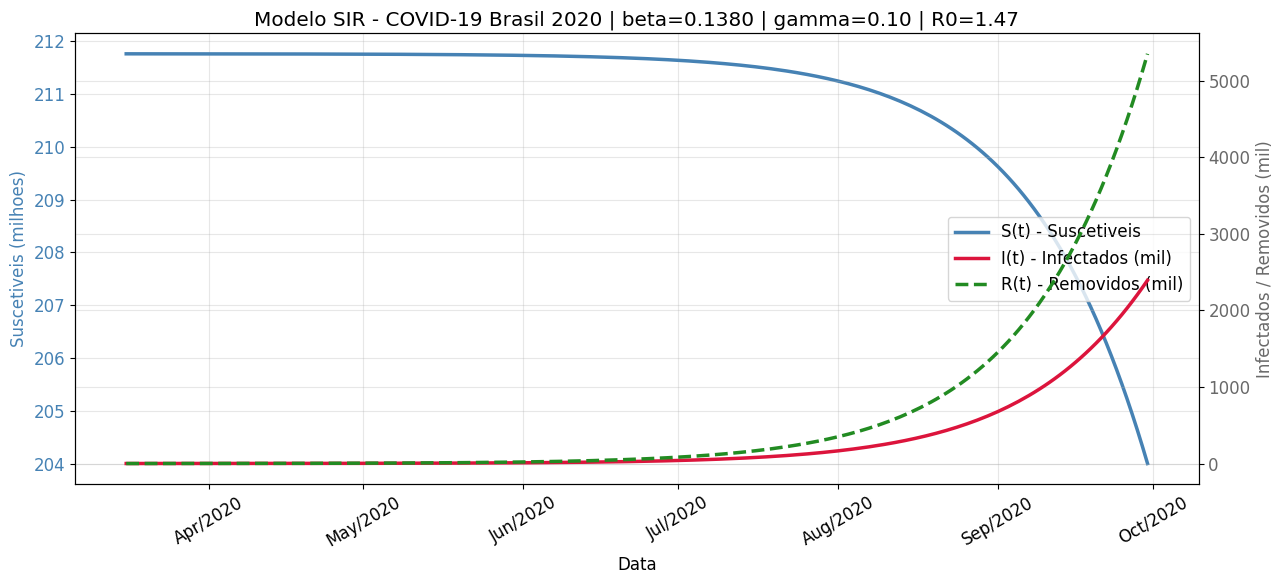

In [24]:
# Grafico 1: S(t), I(t), R(t)
# S(t) usa eixo esquerdo (escala ~211 milhoes).
# I(t) e R(t) usam eixo direito: sao ordens de grandeza menores.
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(datas_sim, S/1e6, color='steelblue', lw=2.5, label='S(t) - Suscetiveis')
ax1.set_xlabel('Data')
ax1.set_ylabel('Suscetiveis (milhoes)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(datas_sim, I/1e3, color='crimson',     lw=2.5, label='I(t) - Infectados (mil)')
ax2.plot(datas_sim, R/1e3, color='forestgreen', lw=2.5, ls='--', label='R(t) - Removidos (mil)')
ax2.set_ylabel('Infectados / Removidos (mil)', color='dimgray')
ax2.tick_params(axis='y', labelcolor='dimgray')

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='center right')

ax1.set_title(f'Modelo SIR - COVID-19 Brasil 2020 | beta={beta_otimo:.4f} | gamma={gamma:.2f} | R0={R0_valor:.2f}')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.savefig('sir_compartimentos.png', dpi=150, bbox_inches='tight')
plt.show()

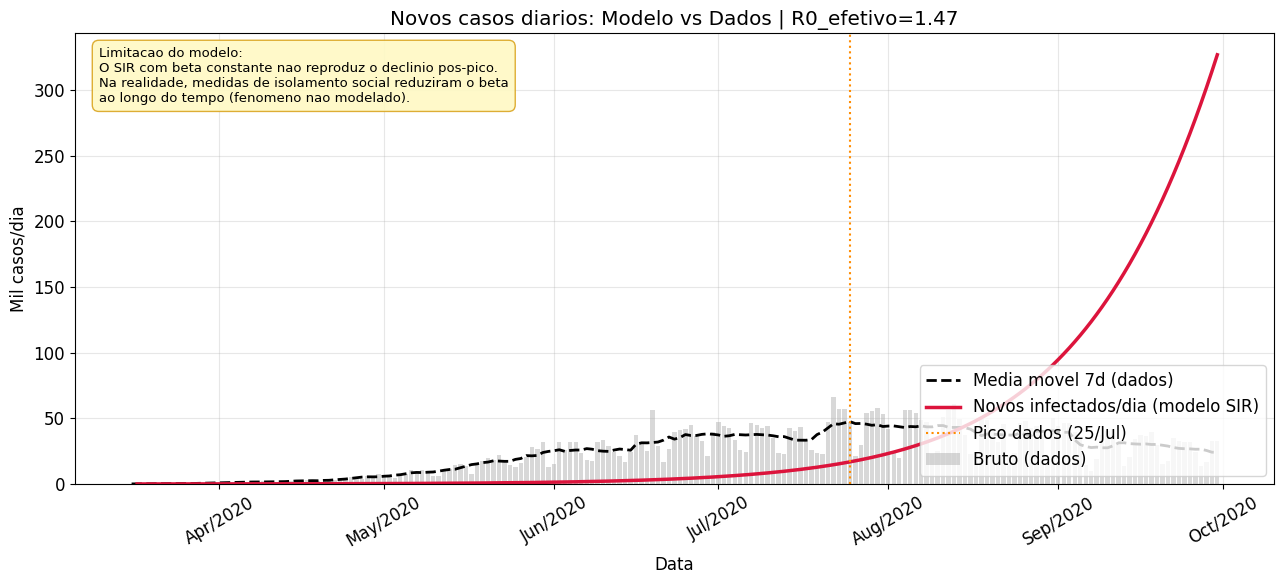

In [25]:
# Grafico 2: Novos casos por dia — Modelo vs Dados
novos_modelo = -np.diff(S)   # novas infeccoes por dia no modelo (-dS/dt)
dia_pico_dados = df_sim.loc[df_sim['casos_suavizados'].idxmax(), 'date']

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(df_sim['date'], df_sim['new_confirmed']/1e3,
       color='gray', alpha=0.30, label='Bruto (dados)')
ax.plot(df_sim['date'], df_sim['casos_suavizados']/1e3,
        color='black', lw=2, ls='--', label='Media movel 7d (dados)')
ax.plot(datas_sim[1:], novos_modelo/1e3,
        color='crimson', lw=2.5, label='Novos infectados/dia (modelo SIR)')
ax.axvline(dia_pico_dados, color='darkorange', lw=1.5, ls=':',
           label=f'Pico dados ({dia_pico_dados.strftime("%d/%b")})')

ax.text(0.02, 0.97,
    'Limitacao do modelo:\nO SIR com beta constante nao reproduz o declinio pos-pico.\n'
    'Na realidade, medidas de isolamento social reduziram o beta\nao longo do tempo (fenomeno nao modelado).',
    transform=ax.transAxes, fontsize=9.5, va='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff9c4', alpha=0.9, edgecolor='goldenrod'))

ax.set_title(f'Novos casos diarios: Modelo vs Dados | R0_efetivo={R0_valor:.2f}')
ax.set_xlabel('Data'); ax.set_ylabel('Mil casos/dia')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('sir_vs_dados.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Grafico 3: Casos acumulados — Modelo vs Dados
casos_reais = int(df_sim.iloc[-1]['last_available_confirmed'])
casos_modelo = int(N - S[-1])

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_sim['date'], df_sim['last_available_confirmed']/1e6,
        color='black', lw=2.5, ls='--', label='Acumulado confirmado (dados)')
ax.plot(datas_sim, (N-S)/1e6, color='crimson', lw=2.5, label='N-S(t) acumulado (modelo)')
ax.axvline(dia_pico_dados, color='darkorange', lw=1.5, ls=':',
           label=f'Pico diario ({dia_pico_dados.strftime("%d/%b")})')

ax.set_title(f'Casos acumulados: Modelo vs Dados | R0_efetivo={R0_valor:.2f}')
ax.set_xlabel('Data'); ax.set_ylabel('Milhoes')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.legend()
ax.annotate(
    f'O modelo estima infeccoes totais incluindo subnotificados.\n'
    f'Modelo: {casos_modelo/1e6:.1f}M | Confirmados: {casos_reais/1e6:.1f}M\n'
    f'O modelo subestima o acumulado pois nao captura o\nperiodo pos-pico (veja Secao 8).',
    xy=(0.02,0.70), xycoords='axes fraction', fontsize=10, color='dimgray',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))
plt.tight_layout()
plt.savefig('sir_acumulado_vs_dados.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Seção 8 — Interpretação dos Resultados

### R₀ efetivo e seu significado

O valor calibrado **R₀ ≈ 1,38** é o **R₀ efetivo** — diferente do R₀ básico do vírus.

- O R₀ básico do SARS-CoV-2 original era **2,5–3,5** (sem intervenções)
- O valor calibrado é menor porque o β real já estava reduzido por medidas de distanciamento   social, uso de máscaras e mudanças de comportamento que estavam em vigor desde março/2020
- R₀ > 1 confirma que a epidemia cresceu — o que é consistente com os dados

### Por que o modelo não reproduz o declínio pós-pico?

Esta é a **limitação central** do modelo SIR com β constante:

O pico dos dados ocorreu em **25 de julho de 2020** e foi seguido de declínio. Esse declínio **não** ocorreu por imunidade de rebanho — apenas ~2,3% da população havia sido infectada até então. Ocorreu porque o **β diminuiu ao longo do tempo** devido às medidas de isolamento.

O SIR com β constante só pode reproduzir uma queda quando S(t) = N/R₀ (imunidade de rebanho), o que exigiria infectar **~27% da população (~56 milhões de pessoas)**. Isso não aconteceu no período modelado.

**Conclusão:** a divergência do modelo após o pico é esperada e matematicamente explicável. Ela é, por si mesma, uma evidência de que as intervenções não farmacológicas tiveram efeito significativo na redução do β.

### Limitações do modelo

1. **β constante:** na realidade β variou com lockdowns, reabertura e comportamento social
2. **Subnotificação:** Brasil testava menos de 10% dos casos em 2020; I₀ é subestimado
3. **Heterogeneidade espacial:** modelo assume mistura homogênea em 8,5 mi km²
4. **γ fixo:** há variação individual no período infeccioso

In [ ]:
novos_obs_v = df_sim['casos_suavizados'].values[1:]
nm_v        = -np.diff(S)
n_v         = min(len(nm_v), len(novos_obs_v))
erros_v     = nm_v[:n_v] - novos_obs_v[:n_v]
idx_p_v     = int(df_sim['casos_suavizados'].idxmax())

print('=' * 55)
print('TABELA RESUMO')
print('=' * 55)
print(f'Periodo        : {DATA_INICIO} a {datas_sim[-1].date()}')
print(f'N              : {N:,}')
print(f'I0             : {I0:,.0f}')
print(f'beta           : {beta_otimo:.4f} dia-1')
print(f'gamma          : {gamma:.4f} dia-1')
print(f'R0 efetivo     : {R0_valor:.2f}')
print(f'Pico dados 7dMA: {int(df_sim["casos_suavizados"].max()):,}/dia em {dia_pico_dados.date()}')
print(f'RMSE cresciment: {np.sqrt(np.mean(erros_v[:idx_p_v]**2)):,.0f} casos/dia')
print(f'RMSE declinio  : {np.sqrt(np.mean(erros_v[idx_p_v:]**2)):,.0f} casos/dia')
print(f'Casos reais    : {casos_reais:,}')
print(f'Modelo (N-S)   : {casos_modelo:,}')
print(f'S+I+R = N?     : {abs(S[-1]+I[-1]+R[-1]-N) < 1}')
print('=' * 55)